In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path

pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")

FIG_DIR = Path("../reports/figures")
METRICS_DIR = Path("../reports/metrics")
MODEL_DIR = Path("../models")
OUT_DIR = Path("../data/processed")

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df = pd.read_csv("../data/processed/train.csv")

TARGET = "log_median_rent"

EXCLUDE_COLS = [
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "avg_monthly_rent",
    "rent_num_properties",
    TARGET
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
y = df[TARGET]

# Drop all-NaN feature columns (safety)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

feature_cols = X.columns.tolist()
print("Rows:", len(df), "Features:", len(feature_cols))


Dropping all-NaN columns: ['school_count', 'avg_ats']
Rows: 175 Features: 18


In [3]:
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=800,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])


In [4]:
hgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=6,
        max_leaf_nodes=31,
        min_samples_leaf=10,
        l2_regularization=0.0
    ))
])


In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate(model, X, y, name):
    rmses = []
    maes = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmses.append(rmse(y_va, pred))
        maes.append(mean_absolute_error(y_va, pred))
    print(f"{name} CV RMSE (log): {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"{name} CV MAE  (log): {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    return np.mean(rmses), np.mean(maes)

rf_cv_rmse, rf_cv_mae = cv_evaluate(rf_pipe, X, y, "RandomForest")
hgb_cv_rmse, hgb_cv_mae = cv_evaluate(hgb_pipe, X, y, "HistGB")


RandomForest CV RMSE (log): 0.2770 ± 0.0444
RandomForest CV MAE  (log): 0.2135 ± 0.0383
HistGB CV RMSE (log): 0.2747 ± 0.0301
HistGB CV MAE  (log): 0.2108 ± 0.0205


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# pick the model with lower CV RMSE
final_model = hgb_pipe if hgb_cv_rmse <= rf_cv_rmse else rf_pipe
final_name = "HistGB" if final_model is hgb_pipe else "RandomForest"

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_rmse_log = rmse(y_test, y_pred)
test_mae_log = mean_absolute_error(y_test, y_pred)

test_mae_dollars = np.mean(np.abs(np.exp(y_test) - np.exp(y_pred)))

print("Final model:", final_name)
print("Test RMSE (log):", test_rmse_log)
print("Test MAE (log):", test_mae_log)
print("Test MAE ($):", test_mae_dollars)


Final model: HistGB
Test RMSE (log): 0.25707333165185636
Test MAE (log): 0.19273101962108563
Test MAE ($): 471.22975941146984


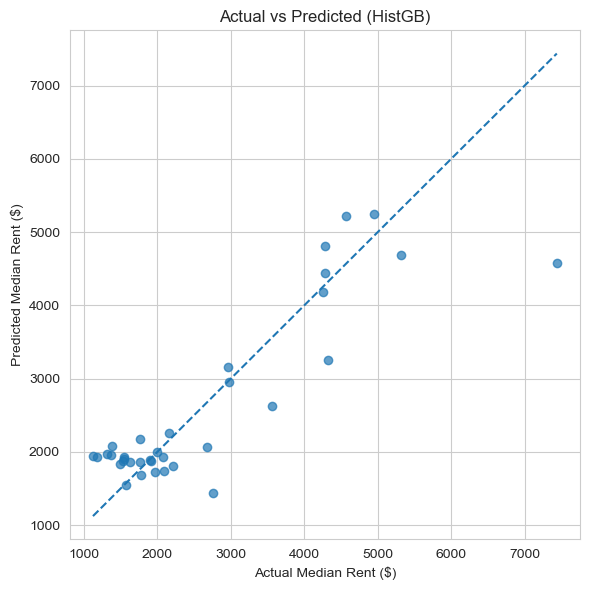

In [7]:
y_true_d = np.exp(y_test)
y_pred_d = np.exp(y_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_d, y_pred_d, alpha=0.7)
mn = min(y_true_d.min(), y_pred_d.min())
mx = max(y_true_d.max(), y_pred_d.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual Median Rent ($)")
plt.ylabel("Predicted Median Rent ($)")
plt.title(f"Actual vs Predicted ({final_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_actual_vs_pred.png", dpi=200)
plt.show()


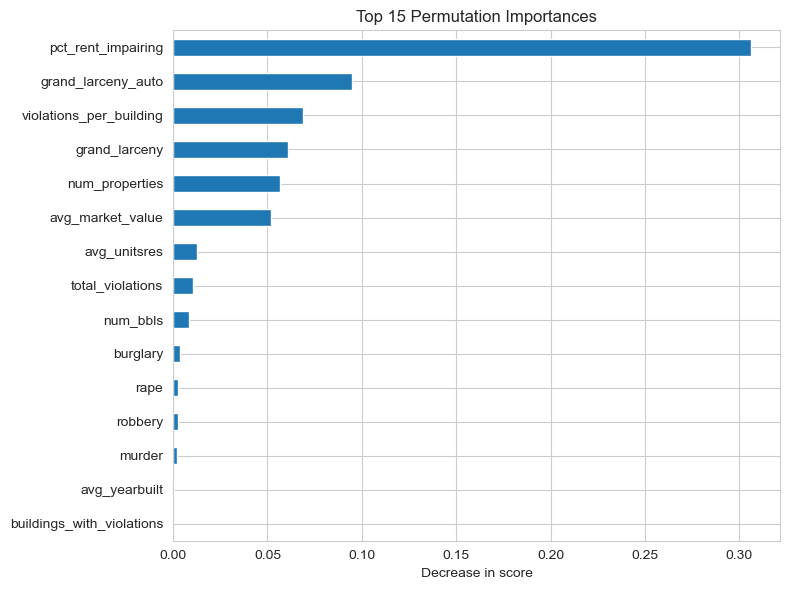

pct_rent_impairing           0.306275
grand_larceny_auto           0.095036
violations_per_building      0.069039
grand_larceny                0.061078
num_properties               0.056802
avg_market_value             0.051861
avg_unitsres                 0.012693
total_violations             0.010410
num_bbls                     0.008590
burglary                     0.003737
rape                         0.002656
robbery                      0.002371
murder                       0.002117
avg_yearbuilt                0.000727
buildings_with_violations    0.000019
avg_unitstotal              -0.000191
felony_assault              -0.001049
rent_impairing_violations   -0.009005
dtype: float64

In [8]:
if final_name == "RandomForest":
    model = final_model.named_steps["model"]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_feature_importance.png", dpi=200)
    plt.show()
else:
    from sklearn.inspection import permutation_importance

    # Use a smaller sample for speed
    r = permutation_importance(final_model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
    importances = pd.Series(r.importances_mean, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Permutation Importances")
    plt.xlabel("Decrease in score")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_feature_importance.png", dpi=200)
    plt.show()

importances.head(20)


In [9]:
# Save model
joblib.dump(final_model, MODEL_DIR / "03_final_model.joblib")

# Save metrics
metrics = {
    "final_model": final_name,
    "rf_cv_rmse_log": float(rf_cv_rmse),
    "hgb_cv_rmse_log": float(hgb_cv_rmse),
    "test_rmse_log": float(test_rmse_log),
    "test_mae_log": float(test_mae_log),
    "test_mae_dollars": float(test_mae_dollars),
    "n_rows": int(len(df)),
    "n_features": int(len(feature_cols))
}

pd.Series(metrics).to_json(METRICS_DIR / "03_metrics.json", indent=2)

# Save test predictions
pred_df = pd.DataFrame({
    "y_true_log": y_test.values,
    "y_pred_log": y_pred,
    "y_true": y_true_d.values,
    "y_pred": y_pred_d
})

pred_df.to_csv(OUT_DIR / "03_test_predictions.csv", index=False)

print("Saved:",
      "\n- model ->", MODEL_DIR / "03_final_model.joblib",
      "\n- metrics ->", METRICS_DIR / "03_metrics.json",
      "\n- figures ->", FIG_DIR,
      "\n- predictions ->", OUT_DIR / "03_test_predictions.csv")


Saved: 
- model -> ../models/03_final_model.joblib 
- metrics -> ../reports/metrics/03_metrics.json 
- figures -> ../reports/figures 
- predictions -> ../data/processed/03_test_predictions.csv
